# Floquet Spectrum Examples

This notebook reproduces the two spectrum-plotting examples from `examples/plot_spectra.py`. It shows how to build the driven Dirac and driven graphene models, compute their Floquet spectra, and visualize the quasienergy structure.


## Imports and Shared Parameters

We first import the package components and define one shared set of physical, drive, and Floquet truncation parameters used by both examples.


In [5]:
import sys
from pathlib import Path

repo_root = Path.cwd()
if not (repo_root / "floquet_toolkit").exists() and (repo_root.parent / "floquet_toolkit").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import numpy as np

from floquet_toolkit.calculators.floquet_spectrum_calculator import FloquetSpectrumCalculator
from floquet_toolkit import (
    DiracModel,
    DiracParameters,
    GrapheneModel,
    GrapheneParameters,
    UnitConvention,
)
from floquet_toolkit.config import (
    DriveParameters,
    FloquetParameters,
    MEV_TO_J,
)

SI_UNITS = UnitConvention.SI_UNITS()
DEFAULT_DIRAC_PARAMS = DiracParameters(
    units=SI_UNITS,
    vf=1.0e6,
    mass=-10.0 * MEV_TO_J,
)
DEFAULT_GRAPHENE_PARAMS = GrapheneParameters(
    units=SI_UNITS,
    vf=1.0e6,
)
DEFAULT_DRIVE_PARAMS = DriveParameters(
    units=SI_UNITS,
    omega=50.0 * MEV_TO_J / SI_UNITS.hbar,
    AL=5.0e-9,
    AR=0.0,
)
DEFAULT_FLOQUET_PARAMS = FloquetParameters(
    n_harmonics=3,
    n_trunc=7,
    n_time=21,
)


## Shared Plotting Helper

This helper computes the Floquet quasienergy spectrum on a rectangular momentum grid and colors each point by its overlap with the selected static band.


In [6]:
def plot_spectrum(
    model,
    floquet_params: FloquetParameters,
    kx_range: tuple[float, float],
    ky_range: tuple[float, float],
    num_kx: int = 151,
    num_ky: int = 25,
    title: str = "Floquet quasienergy spectrum",
):
    spectrum_calculator = FloquetSpectrumCalculator(model, floquet_params)

    kx_values = np.linspace(*kx_range, num=num_kx)
    ky_values = np.linspace(*ky_range, num=num_ky)
    quasi_energy, spectral_weight, band_overlaps = spectrum_calculator.compute_floquet_spectrum(
        kx_values,
        ky_values,
        fold_to_zone=False,
    )
    quasi_energy_mev = quasi_energy / MEV_TO_J

    fig, ax = plt.subplots(figsize=(6, 5))
    for ky_index, _ in enumerate(ky_values):
        energy_slice = quasi_energy_mev[:, ky_index, :]
        weight_slice = spectral_weight[:, ky_index, :]
        overlap_slice = band_overlaps[:, ky_index, :]
        kx_points = np.repeat(kx_values[:, None], energy_slice.shape[1], axis=1)

        mask = weight_slice > 1.0e-4
        ax.scatter(
            kx_points[mask],
            energy_slice[mask],
            s=weight_slice[mask],
            c=overlap_slice[mask],
            cmap="coolwarm",
            alpha=1,
        )

    ax.set_xlabel("kx (1/m)")
    ax.set_ylabel("Quasienergy (meV)")
    ax.set_title(title)
    fig.colorbar(ax.collections[-1], ax=ax, label="Static-band overlap")
    fig.tight_layout()
    plt.show()


## Driven Dirac Spectrum

For the Dirac model, we scan a momentum window set by the Fermi-circle radius. This gives a view of the Floquet quasienergy structure in the continuum model.


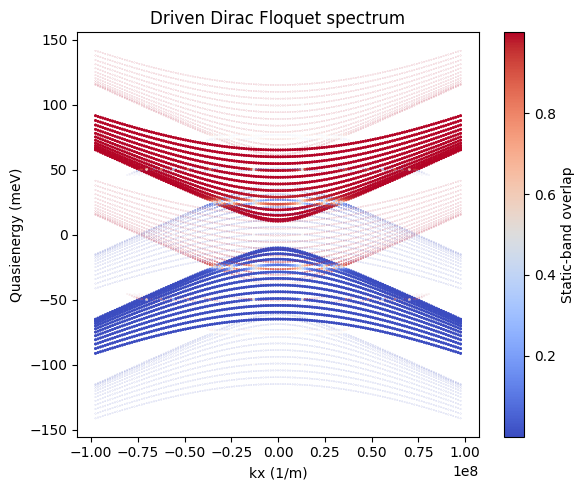

In [7]:
def plot_driven_dirac_spectrum():
    model = DiracModel(DEFAULT_DIRAC_PARAMS, DEFAULT_DRIVE_PARAMS).to_driven_hamiltonian()
    k_radius = np.sqrt(
        DEFAULT_DIRAC_PARAMS.e_fermi**2 - DEFAULT_DIRAC_PARAMS.mass**2
    ) / (DEFAULT_DIRAC_PARAMS.units.hbar * DEFAULT_DIRAC_PARAMS.vf)

    plot_spectrum(
        model,
        DEFAULT_FLOQUET_PARAMS,
        kx_range=(-k_radius, k_radius),
        ky_range=(-k_radius, k_radius),
        num_kx=151,
        num_ky=25,
        title="Driven Dirac Floquet spectrum",
    )

plot_driven_dirac_spectrum()


## Driven Graphene Spectrum

For the graphene model, we focus on a small window around one K point in the Brillouin zone. This highlights how the drive reshapes the quasienergy bands near the Dirac cone.


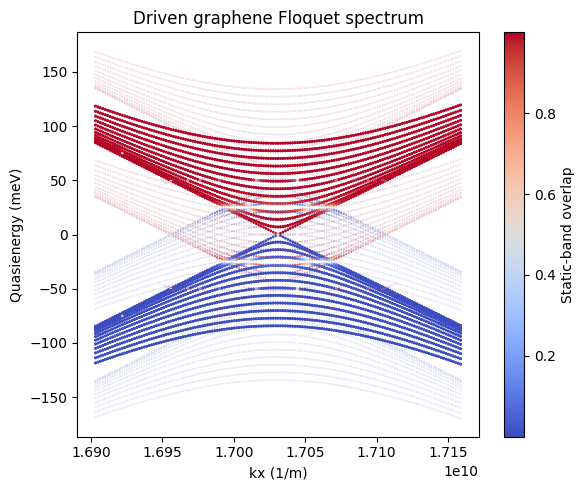

In [8]:
def plot_driven_graphene_spectrum():
    model = GrapheneModel(DEFAULT_GRAPHENE_PARAMS, DEFAULT_DRIVE_PARAMS).to_driven_hamiltonian()
    lattice_spacing = DEFAULT_GRAPHENE_PARAMS.lattice_spacing
    graphene_brillouin_zone = np.pi / lattice_spacing / np.sqrt(3.0)
    kx_k_point = 4.0 * np.pi / (3.0 * np.sqrt(3.0) * lattice_spacing)
    delta_k = 0.01 * graphene_brillouin_zone

    plot_spectrum(
        model,
        DEFAULT_FLOQUET_PARAMS,
        kx_range=(kx_k_point - delta_k, kx_k_point + delta_k),
        ky_range=(-delta_k, delta_k),
        num_kx=151,
        num_ky=25,
        title="Driven graphene Floquet spectrum",
    )

plot_driven_graphene_spectrum()
